In [1]:
!pip install torch torchvision matplotlib seaborn numpy pandas tqdm -q
!pip install thop ptflops torchinfo -q  # For FLOPs counting
!pip install wandb -q  # For experiment tracking

print("✓ All packages installed successfully!")

✓ All packages installed successfully!


In [2]:
# Core PyTorch libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Torchvision for datasets and models
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

# FLOPs counting tools
from thop import profile, clever_format
from ptflops import get_model_complexity_info
from torchinfo import summary

# Weights & Biases for experiment tracking
import wandb

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Utilities
import os
import random
from collections import defaultdict
import copy
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
PyTorch version: 2.9.0+cu126
GPU: Tesla T4


In [3]:
# Login to WandB
wandb.login()

# Initialize WandB project
wandb.init(
    project="cifar10-cnn-assignment",
    name="resnet18-custom-dataloader",
    config={
        "model": "ResNet18",
        "dataset": "CIFAR-10",
        "epochs": 30,
        "batch_size": 128,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "seed": SEED
    }
)

config = wandb.config
print("✓ WandB initialized successfully!")
print(f"Project: {wandb.run.project}")
print(f"Run name: {wandb.run.name}")
print(f"View your results at: {wandb.run.url}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shikhar_dave (shikhar_dave-iit-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ WandB initialized successfully!
Project: cifar10-cnn-assignment
Run name: resnet18-custom-dataloader
View your results at: https://wandb.ai/shikhar_dave-iit-jodhpur/cifar10-cnn-assignment/runs/bmv5teg1


In [4]:
class CustomCIFAR10Dataset(Dataset):
    """
    Custom Dataset class for CIFAR-10.

    This class wraps the standard CIFAR-10 dataset and allows for:
    - Custom transformations
    - Data augmentation
    - Easy modification of data loading logic
    """

    def __init__(self, root='./data', train=True, transform=None, download=True):
        """
        Args:
            root (str): Root directory for dataset
            train (bool): If True, load training set, else test set
            transform (callable, optional): Optional transform to be applied on images
            download (bool): If True, downloads the dataset
        """
        # Load the original CIFAR-10 dataset
        self.cifar10 = datasets.CIFAR10(
            root=root,
            train=train,
            download=download,
            transform=None  # We'll apply transforms manually
        )

        self.transform = transform
        self.train = train

        # CIFAR-10 class names
        self.classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']

        print(f"✓ Custom CIFAR-10 Dataset initialized")
        print(f"  Split: {'Train' if train else 'Test'}")
        print(f"  Total samples: {len(self.cifar10)}")
        print(f"  Classes: {len(self.classes)}")

    def __len__(self):
        """Return the total number of samples."""
        return len(self.cifar10)

    def __getitem__(self, idx):
        """
        Get a single sample.

        Args:
            idx (int): Index of the sample

        Returns:
            tuple: (image, label) where image is a tensor and label is an integer
        """
        # Get image and label from the original dataset
        image, label = self.cifar10[idx]

        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)

        return image, label

    def get_class_name(self, label):
        """Convert label index to class name."""
        return self.classes[label]


# Define data transformations
# Training transforms with data augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# Test transforms without augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# Create custom datasets
train_dataset = CustomCIFAR10Dataset(
    root='./data',
    train=True,
    transform=train_transform,
    download=True
)

test_dataset = CustomCIFAR10Dataset(
    root='./data',
    train=False,
    transform=test_transform,
    download=True
)

# Create validation set from training set (80-20 split)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f"\n✓ Dataset splits created:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

# Create DataLoaders
BATCH_SIZE = config.batch_size

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n✓ DataLoaders created with batch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

100%|██████████| 170M/170M [00:05<00:00, 29.7MB/s]


✓ Custom CIFAR-10 Dataset initialized
  Split: Train
  Total samples: 50000
  Classes: 10
✓ Custom CIFAR-10 Dataset initialized
  Split: Test
  Total samples: 10000
  Classes: 10

✓ Dataset splits created:
  Training samples: 40000
  Validation samples: 10000
  Test samples: 10000

✓ DataLoaders created with batch size: 128
  Train batches: 313
  Validation batches: 79
  Test batches: 79


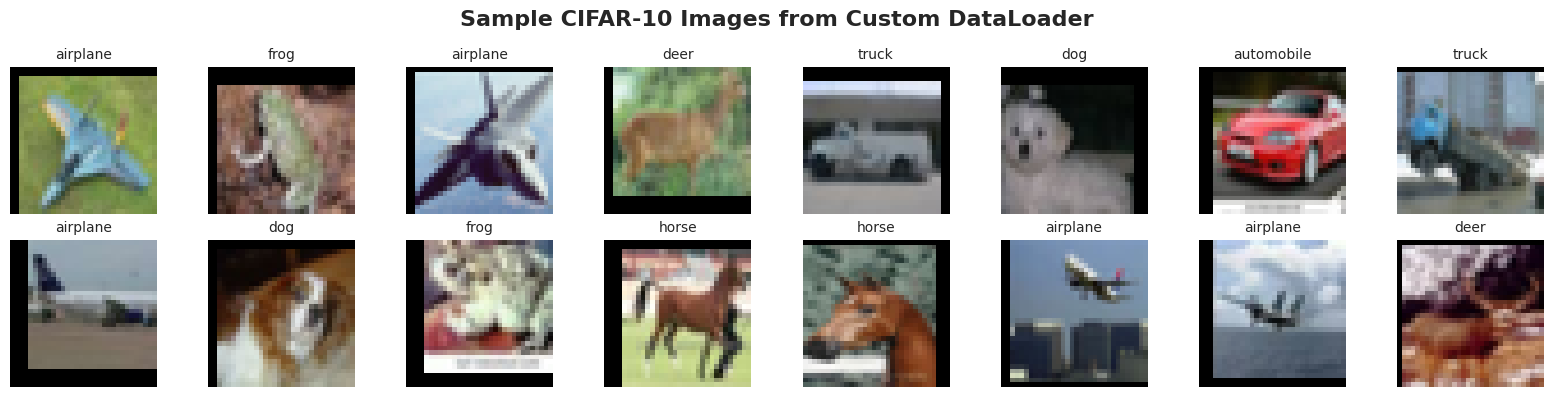

✓ Sample images visualized and logged to WandB


In [5]:
# Function to denormalize images for visualization
def denormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return img * std + mean

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Visualize sample images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Sample CIFAR-10 Images from Custom DataLoader', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    img = denormalize(images[idx])
    img = torch.clamp(img, 0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(test_dataset.get_class_name(labels[idx].item()), fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Log to WandB
wandb.log({"sample_images": wandb.Image(fig)})
plt.close()

print("✓ Sample images visualized and logged to WandB")

In [6]:
# Load pre-trained ResNet18
model = models.resnet18(pretrained=True)

# Modify the final layer for CIFAR-10 (10 classes)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Move model to device
model = model.to(device)

print("✓ ResNet18 model loaded and modified for CIFAR-10")
print(f"  Model device: {next(model.parameters()).device}")
print(f"\nModel Architecture:")
print(model)

# Log model architecture to WandB
wandb.watch(model, log="all", log_freq=100)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 45.0MB/s]


✓ ResNet18 model loaded and modified for CIFAR-10
  Model device: cuda:0

Model Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1

In [7]:
print("="*80)
print("MODEL COMPLEXITY ANALYSIS")
print("="*80)

# Method 1: Using thop
print("\n1. FLOPs Analysis using THOP:")
print("-"*80)
model_copy = copy.deepcopy(model)
input_tensor = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model_copy, inputs=(input_tensor,), verbose=False)
flops_formatted, params_formatted = clever_format([flops, params], "%.3f")

print(f"Total FLOPs: {flops_formatted}")
print(f"Total Parameters: {params_formatted}")
print(f"Raw FLOPs: {flops:,.0f}")
print(f"Raw Parameters: {params:,.0f}")

# Method 2: Using ptflops
print("\n2. Model Complexity using PTFLOPS:")
print("-"*80)
macs, params_ptflops = get_model_complexity_info(
    model,
    (3, 32, 32),
    as_strings=True,
    print_per_layer_stat=False,
    verbose=False
)
print(f"Computational complexity (MACs): {macs}")
print(f"Number of parameters: {params_ptflops}")

# Method 3: Using torchinfo
print("\n3. Detailed Model Summary using TorchInfo:")
print("-"*80)
model_stats = summary(
    model,
    input_size=(1, 3, 32, 32),
    device=device,
    verbose=0
)
print(model_stats)

# Calculate additional metrics
print("\n4. Additional Metrics:")
print("-"*80)
flops_per_sample = flops
flops_per_batch = flops_per_sample * BATCH_SIZE
total_batches = len(train_loader) * config.epochs
total_flops_training = flops_per_batch * total_batches

print(f"FLOPs per sample: {flops_per_sample:,.0f}")
print(f"FLOPs per batch ({BATCH_SIZE} samples): {flops_per_batch:,.0f}")
print(f"Total training batches ({config.epochs} epochs): {total_batches:,}")
print(f"Total FLOPs for entire training: {total_flops_training:.2e}")

# Memory estimation
param_memory = params * 4 / (1024**2)  # Parameters in MB (float32)
activation_memory = model_stats.total_output_bytes / (1024**2)  # Activations in MB
total_memory = param_memory * 4 + activation_memory  # Including gradients and optimizer state

print(f"\nMemory Requirements (estimated):")
print(f"  Parameters: {param_memory:.2f} MB")
print(f"  Activations: {activation_memory:.2f} MB")
print(f"  Total (with gradients & optimizer): {total_memory:.2f} MB")

# Log to WandB
wandb.log({
    "model/total_flops": flops,
    "model/total_params": params,
    "model/flops_per_sample": flops_per_sample,
    "model/flops_per_batch": flops_per_batch,
    "model/total_training_flops": total_flops_training,
    "model/param_memory_mb": param_memory,
    "model/total_memory_mb": total_memory
})

print("\n✓ FLOPs analysis complete and logged to WandB")
print("="*80)

MODEL COMPLEXITY ANALYSIS

1. FLOPs Analysis using THOP:
--------------------------------------------------------------------------------
Total FLOPs: 37.220M
Total Parameters: 11.182M
Raw FLOPs: 37,220,352
Raw Parameters: 11,181,642

2. Model Complexity using PTFLOPS:
--------------------------------------------------------------------------------
Computational complexity (MACs): 37.25 MMac
Number of parameters: 11.18 M

3. Detailed Model Summary using TorchInfo:
--------------------------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 16, 16]           9,408
├─BatchNorm2d: 1-2                       [1, 64, 16, 16]           128
├─ReLU: 1-3                              [1, 64, 16, 16]           --
├─MaxPool2d: 1-4                         [1, 64, 8, 8]             --
├─Sequential: 1-5    

In [8]:
class GradientWeightTracker:
    """
    Track gradients and weights during training.

    This class monitors:
    - Gradient statistics (mean, std, norm, min, max)
    - Weight statistics (mean, std, norm)
    - Weight updates
    - Layer-wise gradient flow
    """

    def __init__(self, model):
        self.model = model
        self.metrics = defaultdict(lambda: defaultdict(list))
        self.step = 0

        # Store initial weights for tracking updates
        self.prev_weights = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.prev_weights[name] = param.data.clone()

    def update(self, log_to_wandb=False):
        """
        Update gradient and weight statistics.

        Args:
            log_to_wandb (bool): If True, log metrics to WandB
        """
        self.step += 1
        wandb_metrics = {}

        for name, param in self.model.named_parameters():
            if param.requires_grad and param.grad is not None:
                # Get gradient and weight data
                grad = param.grad.data
                weight = param.data

                # Calculate gradient statistics
                grad_mean = grad.mean().item()
                grad_std = grad.std().item()
                grad_norm = grad.norm().item()
                grad_min = grad.min().item()
                grad_max = grad.max().item()

                # Calculate weight statistics
                weight_mean = weight.mean().item()
                weight_std = weight.std().item()
                weight_norm = weight.norm().item()

                # Calculate weight update
                if name in self.prev_weights:
                    weight_update = (weight - self.prev_weights[name]).norm().item()
                    self.metrics[name]['weight_update'].append(weight_update)
                    wandb_metrics[f"weight_update/{name}"] = weight_update

                # Store metrics
                self.metrics[name]['grad_mean'].append(grad_mean)
                self.metrics[name]['grad_std'].append(grad_std)
                self.metrics[name]['grad_norm'].append(grad_norm)
                self.metrics[name]['grad_min'].append(grad_min)
                self.metrics[name]['grad_max'].append(grad_max)
                self.metrics[name]['weight_mean'].append(weight_mean)
                self.metrics[name]['weight_std'].append(weight_std)
                self.metrics[name]['weight_norm'].append(weight_norm)

                # Prepare WandB metrics
                if log_to_wandb:
                    wandb_metrics.update({
                        f"gradients/{name}/mean": grad_mean,
                        f"gradients/{name}/std": grad_std,
                        f"gradients/{name}/norm": grad_norm,
                        f"weights/{name}/mean": weight_mean,
                        f"weights/{name}/std": weight_std,
                        f"weights/{name}/norm": weight_norm,
                    })

                # Update previous weights
                self.prev_weights[name] = weight.clone()

        # Log to WandB
        if log_to_wandb and wandb_metrics:
            wandb.log(wandb_metrics, step=self.step)

    def plot_gradient_flow(self, epoch, save_to_wandb=True):
        """
        Plot gradient flow through the network.

        Args:
            epoch (int): Current epoch number
            save_to_wandb (bool): If True, log plot to WandB
        """
        # Collect current gradient norms
        layers = []
        grad_norms = []

        for name, param in self.model.named_parameters():
            if param.requires_grad and param.grad is not None:
                layers.append(name.replace('.weight', '').replace('.bias', ''))
                grad_norms.append(param.grad.norm().item())

        # Create plot
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.bar(range(len(grad_norms)), grad_norms, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_xlabel('Layers', fontsize=12, fontweight='bold')
        ax.set_ylabel('Gradient Norm', fontsize=12, fontweight='bold')
        ax.set_title(f'Gradient Flow Through Network (Epoch {epoch})',
                    fontsize=14, fontweight='bold')
        ax.set_xticks(range(len(layers)))
        ax.set_xticklabels(layers, rotation=90, ha='right', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        if save_to_wandb:
            wandb.log({f"gradient_flow/epoch_{epoch}": wandb.Image(fig)})

        plt.show()
        plt.close()

    def plot_weight_evolution(self, layer_name, save_to_wandb=True):
        """
        Plot weight evolution for a specific layer.

        Args:
            layer_name (str): Name of the layer
            save_to_wandb (bool): If True, log plot to WandB
        """
        if layer_name not in self.metrics:
            print(f"Layer {layer_name} not found in metrics")
            return

        steps = range(len(self.metrics[layer_name]['weight_mean']))

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'Weight Evolution: {layer_name}', fontsize=16, fontweight='bold')

        # Weight mean and std
        axes[0, 0].plot(steps, self.metrics[layer_name]['weight_mean'], label='Mean', linewidth=2)
        axes[0, 0].plot(steps, self.metrics[layer_name]['weight_std'], label='Std', linewidth=2)
        axes[0, 0].set_xlabel('Steps')
        axes[0, 0].set_ylabel('Value')
        axes[0, 0].set_title('Weight Mean & Std')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Weight norm
        axes[0, 1].plot(steps, self.metrics[layer_name]['weight_norm'],
                       color='green', linewidth=2)
        axes[0, 1].set_xlabel('Steps')
        axes[0, 1].set_ylabel('Norm')
        axes[0, 1].set_title('Weight Norm')
        axes[0, 1].grid(True, alpha=0.3)

        # Gradient norm
        axes[1, 0].plot(steps, self.metrics[layer_name]['grad_norm'],
                       color='red', linewidth=2)
        axes[1, 0].set_xlabel('Steps')
        axes[1, 0].set_ylabel('Gradient Norm')
        axes[1, 0].set_title('Gradient Norm Over Time')
        axes[1, 0].grid(True, alpha=0.3)

        # Weight updates
        if 'weight_update' in self.metrics[layer_name]:
            axes[1, 1].plot(steps, self.metrics[layer_name]['weight_update'],
                           color='purple', linewidth=2)
            axes[1, 1].set_xlabel('Steps')
            axes[1, 1].set_ylabel('Update Magnitude')
            axes[1, 1].set_title('Weight Update Magnitude')
            axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_to_wandb:
            wandb.log({f"weight_evolution/{layer_name}": wandb.Image(fig)})

        plt.show()
        plt.close()

    def summary(self):
        """Print summary statistics."""
        print("\n" + "="*80)
        print("GRADIENT & WEIGHT TRACKER SUMMARY")
        print("="*80)
        print(f"Total steps tracked: {self.step}")
        print("\nLayer-wise Statistics (Last Step):")
        print("-"*80)

        for name in sorted(self.metrics.keys()):
            if 'weight' in name.lower():
                print(f"\n{name}:")
                print(f"  Gradient Norm: {self.metrics[name]['grad_norm'][-1]:.6f}")
                print(f"  Gradient Mean: {self.metrics[name]['grad_mean'][-1]:.6f}")
                print(f"  Weight Norm:   {self.metrics[name]['weight_norm'][-1]:.6f}")
                if 'weight_update' in self.metrics[name]:
                    print(f"  Weight Update: {self.metrics[name]['weight_update'][-1]:.6f}")

# Create gradient tracker
gradient_tracker = GradientWeightTracker(model)
print("✓ Gradient and Weight Tracker initialized")

✓ Gradient and Weight Tracker initialized


In [10]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("✓ Training components initialized")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr={config.learning_rate})")
print(f"  Scheduler: ReduceLROnPlateau")

✓ Training components initialized
  Loss function: CrossEntropyLoss
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau


In [11]:
def train_one_epoch(epoch):
    """
    Train for one epoch.

    Args:
        epoch (int): Current epoch number

    Returns:
        float: Average training loss
        float: Training accuracy
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{config.epochs} [Train]')

    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update gradient tracker (every 50 batches to reduce overhead)
        if batch_idx % 50 == 0:
            gradient_tracker.update(log_to_wandb=True)

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Optimizer step
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

        # Log to WandB (every 50 batches)
        if batch_idx % 50 == 0:
            wandb.log({
                'train/batch_loss': loss.item(),
                'train/batch_acc': 100. * correct / total,
                'train/learning_rate': optimizer.param_groups[0]['lr']
            })

    # Calculate epoch statistics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def evaluate(data_loader, split_name='Validation'):
    """
    Evaluate the model.

    Args:
        data_loader: DataLoader to evaluate on
        split_name (str): Name of the split for logging

    Returns:
        float: Average loss
        float: Accuracy
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(data_loader, desc=f'{split_name}')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    avg_loss = running_loss / len(data_loader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy, all_preds, all_labels


print("✓ Training and evaluation functions defined")

✓ Training and evaluation functions defined


STARTING TRAINING
Total epochs: 30
Training batches per epoch: 313
Validation batches: 79

Epoch 1/30
--------------------------------------------------------------------------------


Epoch 1/30 [Train]:  58%|█████▊    | 183/313 [00:14<00:07, 17.46it/s, loss=0.9517, acc=57.12%]wandb: WARNING Tried to log to step 2 that is less than the current step 3. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 3 that is less than the current step 4. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 4 that is less than the current step 5. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Validation:   5%|▌         | 4/79 [00:00<00:05, 14.81it/s, loss=0.9241, acc=66.60%]wandb: WARNING Tried to log to step 5 that is less than the current step 6. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of or


Epoch 1 Summary:
  Train Loss: 1.1066 | Train Acc: 62.08%
  Val Loss:   0.9518 | Val Acc:   67.46%
  ★ New best model saved! (Val Acc: 67.46%)
--------------------------------------------------------------------------------

Epoch 2/30
--------------------------------------------------------------------------------


Epoch 2/30 [Train]:  27%|██▋       | 85/313 [00:06<00:19, 11.50it/s, loss=0.9215, acc=71.59%]wandb: WARNING Tried to log to step 8 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 9 that is less than the current step 11. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 2/30 [Train]:  73%|███████▎  | 229/313 [00:16<00:05, 15.55it/s, loss=0.7162, acc=72.74%]wandb: WARNING Tried to log to step 10 that is less than the current step 12. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 11 that is less than the current step 13. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to lo


Epoch 2 Summary:
  Train Loss: 0.7909 | Train Acc: 73.26%
  Val Loss:   0.7783 | Val Acc:   73.80%
  ★ New best model saved! (Val Acc: 73.80%)
--------------------------------------------------------------------------------

Epoch 3/30
--------------------------------------------------------------------------------


...


Epoch 3 Summary:
  Train Loss: 0.6896 | Train Acc: 76.56%
  Val Loss:   0.7861 | Val Acc:   73.06%
--------------------------------------------------------------------------------

Epoch 4/30
--------------------------------------------------------------------------------


Epoch 4/30 [Train]:   5%|▌         | 16/313 [00:01<00:26, 11.24it/s, loss=0.6476, acc=78.54%]wandb: WARNING Tried to log to step 21 that is less than the current step 24. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 22 that is less than the current step 26. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 4/30 [Train]:  48%|████▊     | 150/313 [00:11<00:09, 17.83it/s, loss=0.7790, acc=78.42%]wandb: WARNING Tried to log to step 23 that is less than the current step 27. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 24 that is less than the current step 28. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to 


Epoch 4 Summary:
  Train Loss: 0.6263 | Train Acc: 78.69%
  Val Loss:   0.6380 | Val Acc:   78.10%
  ★ New best model saved! (Val Acc: 78.10%)
--------------------------------------------------------------------------------

Epoch 5/30
--------------------------------------------------------------------------------


Epoch 5/30 [Train]:  18%|█▊        | 56/313 [00:03<00:15, 16.27it/s, loss=0.8813, acc=80.19%]wandb: WARNING Tried to log to step 28 that is less than the current step 32. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 29 that is less than the current step 34. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 30 that is less than the current step 35. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 5/30 [Train]:  63%|██████▎   | 197/313 [00:13<00:07, 16.39it/s, loss=0.6111, acc=80.14%]wandb: WARNING Tried to log to step 31 that is less than the current step 36. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to 


Epoch 5 Summary:
  Train Loss: 0.5781 | Train Acc: 80.29%
  Val Loss:   0.6326 | Val Acc:   78.07%

  Generating gradient flow visualization...


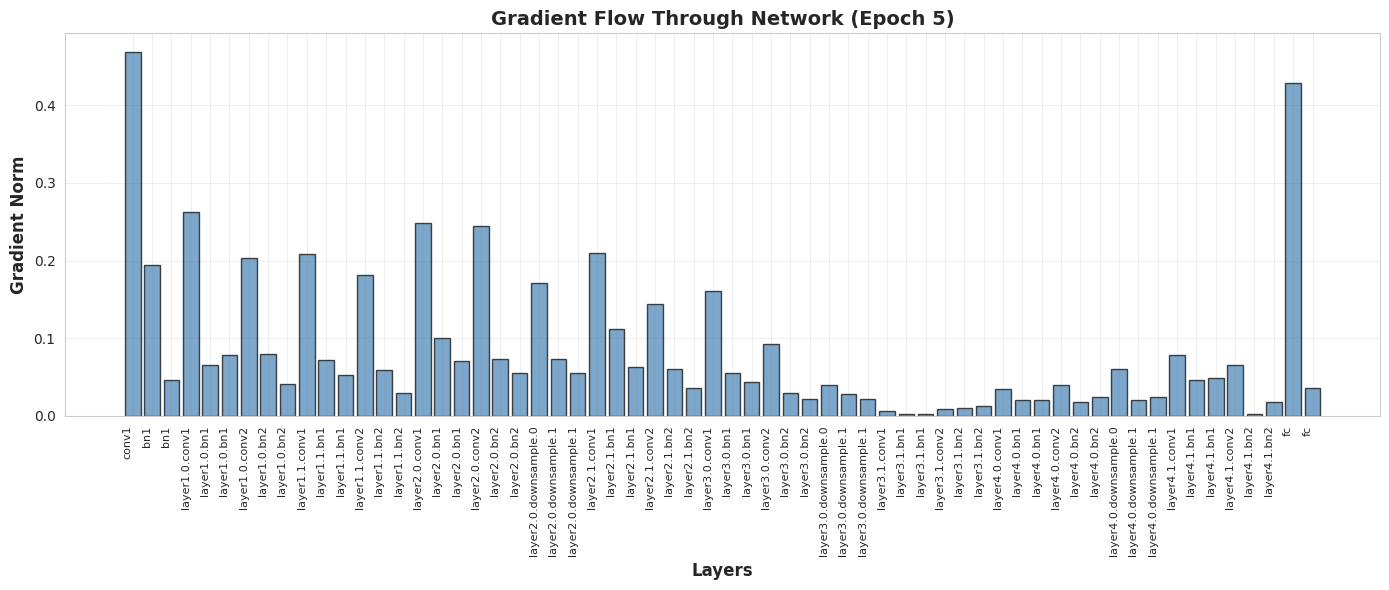

--------------------------------------------------------------------------------

Epoch 6/30
--------------------------------------------------------------------------------


Epoch 6/30 [Train]:  30%|███       | 95/313 [00:06<00:13, 16.65it/s, loss=0.6107, acc=81.13%]wandb: WARNING Tried to log to step 36 that is less than the current step 43. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 37 that is less than the current step 44. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 6/30 [Train]:  74%|███████▍  | 231/313 [00:16<00:05, 16.11it/s, loss=0.7514, acc=81.34%]wandb: WARNING Tried to log to step 38 that is less than the current step 45. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 39 that is less than the current step 46. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to 


Epoch 6 Summary:
  Train Loss: 0.5415 | Train Acc: 81.42%
  Val Loss:   0.5956 | Val Acc:   79.40%
  ★ New best model saved! (Val Acc: 79.40%)
--------------------------------------------------------------------------------

Epoch 7/30
--------------------------------------------------------------------------------


Epoch 7/30 [Train]:  41%|████      | 129/313 [00:08<00:16, 11.04it/s, loss=0.5558, acc=82.79%]wandb: WARNING Tried to log to step 43 that is less than the current step 51. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 44 that is less than the current step 52. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 45 that is less than the current step 53. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 7/30 [Train]:  86%|████████▌ | 268/313 [00:18<00:02, 16.20it/s, loss=0.4332, acc=82.67%]wandb: WARNING Tried to log to step 46 that is less than the current step 54. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to


Epoch 7 Summary:
  Train Loss: 0.5151 | Train Acc: 82.69%
  Val Loss:   0.6069 | Val Acc:   79.04%
--------------------------------------------------------------------------------

Epoch 8/30
--------------------------------------------------------------------------------


...


Epoch 8 Summary:
  Train Loss: 0.4860 | Train Acc: 83.52%
  Val Loss:   0.5867 | Val Acc:   79.90%
  ★ New best model saved! (Val Acc: 79.90%)
--------------------------------------------------------------------------------

Epoch 9/30
--------------------------------------------------------------------------------


Epoch 9/30 [Train]:  17%|█▋        | 54/313 [00:03<00:20, 12.49it/s, loss=0.3494, acc=84.64%]wandb: WARNING Tried to log to step 57 that is less than the current step 67. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 58 that is less than the current step 68. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 9/30 [Train]:  60%|██████    | 188/313 [00:13<00:07, 17.02it/s, loss=0.4227, acc=84.16%]wandb: WARNING Tried to log to step 59 that is less than the current step 69. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 60 that is less than the current step 70. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to 


Epoch 9 Summary:
  Train Loss: 0.4671 | Train Acc: 83.94%
  Val Loss:   0.5538 | Val Acc:   80.68%
  ★ New best model saved! (Val Acc: 80.68%)
--------------------------------------------------------------------------------

Epoch 10/30
--------------------------------------------------------------------------------


Epoch 10/30 [Train]:  28%|██▊       | 88/313 [00:05<00:15, 14.75it/s, loss=0.3548, acc=85.03%]wandb: WARNING Tried to log to step 64 that is less than the current step 75. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 65 that is less than the current step 76. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 10/30 [Train]:  72%|███████▏  | 224/313 [00:15<00:05, 16.82it/s, loss=0.4631, acc=84.82%]wandb: WARNING Tried to log to step 67 that is less than the current step 78. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 68 that is less than the current step 79. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric t


Epoch 10 Summary:
  Train Loss: 0.4398 | Train Acc: 84.79%
  Val Loss:   0.5461 | Val Acc:   81.62%
  ★ New best model saved! (Val Acc: 81.62%)

  Generating gradient flow visualization...


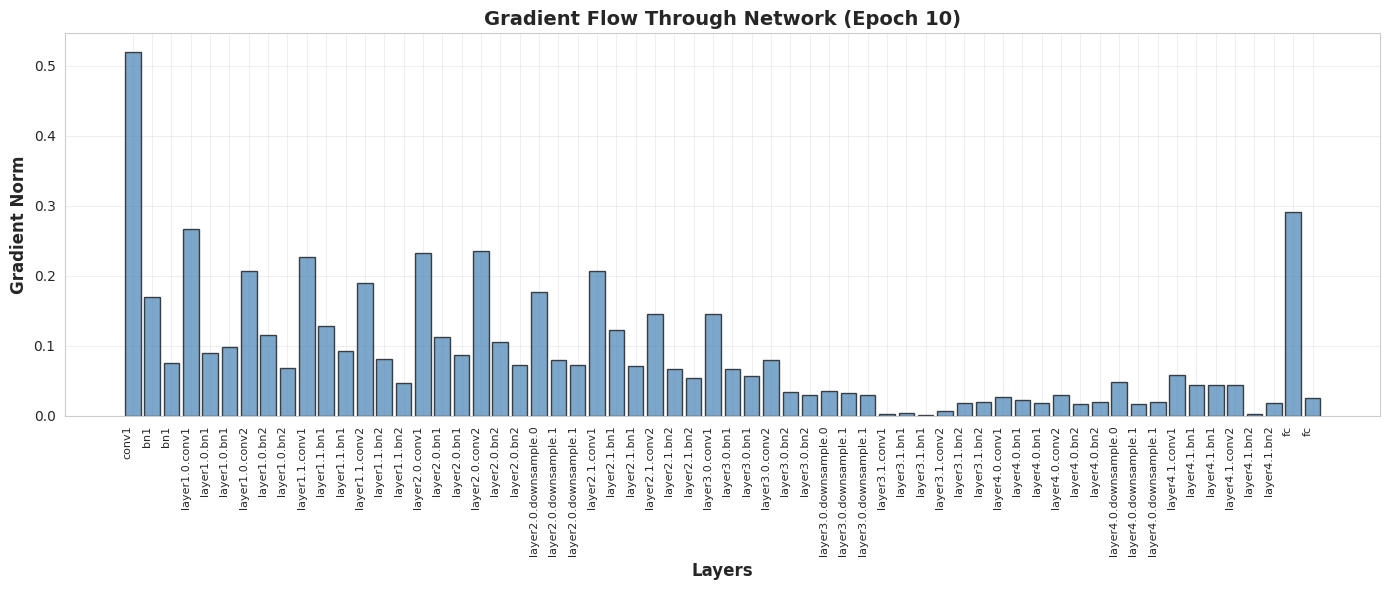

--------------------------------------------------------------------------------

Epoch 11/30
--------------------------------------------------------------------------------


Epoch 11/30 [Train]:  35%|███▌      | 111/313 [00:07<00:12, 16.76it/s, loss=0.5173, acc=85.71%]wandb: WARNING Tried to log to step 71 that is less than the current step 84. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 72 that is less than the current step 85. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 73 that is less than the current step 86. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 11/30 [Train]:  79%|███████▉  | 247/313 [00:17<00:03, 17.32it/s, loss=0.3870, acc=85.49%]wandb: WARNING Tried to log to step 74 that is less than the current step 87. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric 


Epoch 11 Summary:
  Train Loss: 0.4268 | Train Acc: 85.52%
  Val Loss:   0.5186 | Val Acc:   82.62%
  ★ New best model saved! (Val Acc: 82.62%)
--------------------------------------------------------------------------------

Epoch 12/30
--------------------------------------------------------------------------------


Epoch 12/30 [Train]:  26%|██▌       | 82/313 [00:05<00:14, 15.95it/s, loss=0.4045, acc=86.92%]wandb: WARNING Tried to log to step 78 that is less than the current step 92. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 79 that is less than the current step 93. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 12/30 [Train]:  66%|██████▋   | 208/313 [00:15<00:06, 16.45it/s, loss=0.5012, acc=86.26%]wandb: WARNING Tried to log to step 80 that is less than the current step 94. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 81 that is less than the current step 95. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric t


Epoch 12 Summary:
  Train Loss: 0.4063 | Train Acc: 86.13%
  Val Loss:   0.5226 | Val Acc:   81.84%
--------------------------------------------------------------------------------

Epoch 13/30
--------------------------------------------------------------------------------


...


Epoch 13 Summary:
  Train Loss: 0.3927 | Train Acc: 86.57%
  Val Loss:   0.5470 | Val Acc:   81.81%
--------------------------------------------------------------------------------

Epoch 14/30
--------------------------------------------------------------------------------


Epoch 14/30 [Train]:  36%|███▌      | 113/313 [00:15<00:20,  9.72it/s, loss=0.3757, acc=87.35%]wandb: WARNING Tried to log to step 93 that is less than the current step 109. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 94 that is less than the current step 110. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 14/30 [Train]:  94%|█████████▍| 294/313 [00:35<00:02,  7.15it/s, loss=0.4004, acc=86.97%]wandb: WARNING Tried to log to step 96 that is less than the current step 112. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 97 that is less than the current step 113. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-met


Epoch 14 Summary:
  Train Loss: 0.3789 | Train Acc: 86.96%
  Val Loss:   0.5346 | Val Acc:   82.36%
--------------------------------------------------------------------------------

Epoch 15/30
--------------------------------------------------------------------------------


Epoch 15/30 [Train]:  10%|█         | 32/313 [00:02<00:17, 15.93it/s, loss=0.3356, acc=87.65%]wandb: WARNING Tried to log to step 98 that is less than the current step 114. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 99 that is less than the current step 116. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 15/30 [Train]:  53%|█████▎    | 166/313 [00:12<00:09, 14.98it/s, loss=0.3166, acc=87.92%]wandb: WARNING Tried to log to step 101 that is less than the current step 118. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 102 that is less than the current step 119. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-me


Epoch 15 Summary:
  Train Loss: 0.3586 | Train Acc: 87.62%
  Val Loss:   0.5112 | Val Acc:   82.54%

  Generating gradient flow visualization...


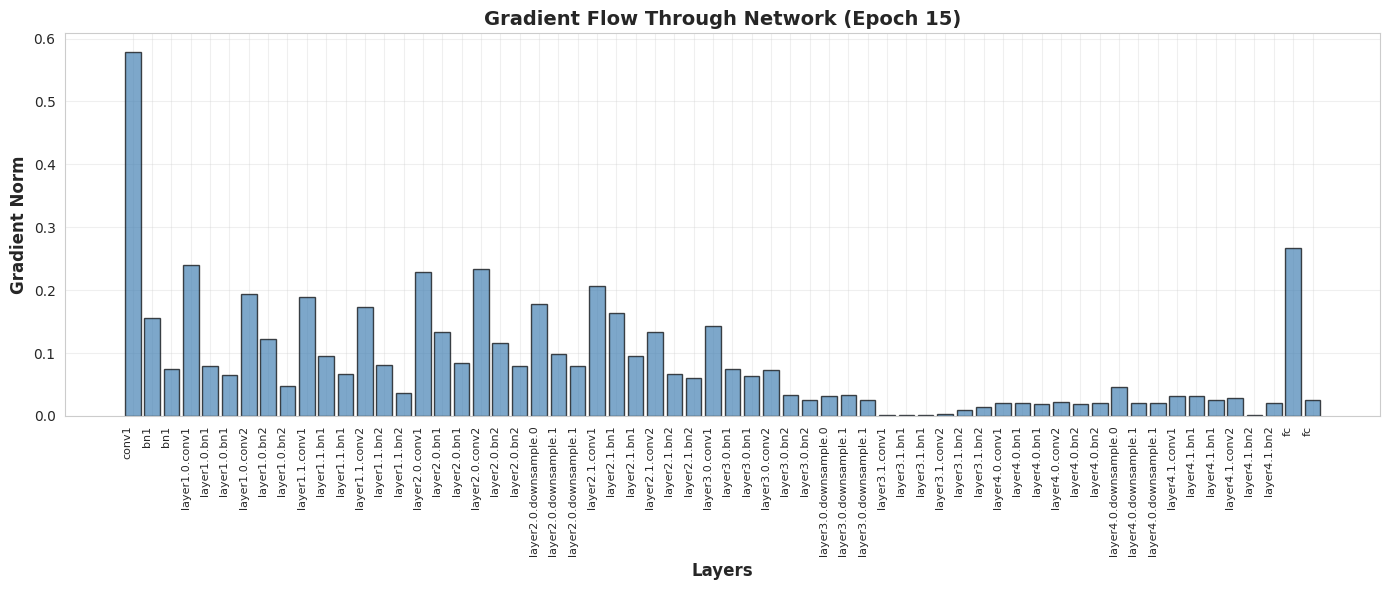

--------------------------------------------------------------------------------

Epoch 16/30
--------------------------------------------------------------------------------


Epoch 16/30 [Train]:  16%|█▌        | 50/313 [00:03<00:15, 17.02it/s, loss=0.4218, acc=88.69%]wandb: WARNING Tried to log to step 106 that is less than the current step 125. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 107 that is less than the current step 126. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 16/30 [Train]:  60%|██████    | 188/313 [00:13<00:07, 16.45it/s, loss=0.3220, acc=88.04%]wandb: WARNING Tried to log to step 108 that is less than the current step 127. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 109 that is less than the current step 128. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 16 Summary:
  Train Loss: 0.3564 | Train Acc: 87.69%
  Val Loss:   0.5194 | Val Acc:   82.38%
--------------------------------------------------------------------------------

Epoch 17/30
--------------------------------------------------------------------------------


Epoch 17/30 [Train]:  27%|██▋       | 85/313 [00:06<00:16, 13.93it/s, loss=0.3682, acc=88.80%]wandb: WARNING Tried to log to step 113 that is less than the current step 133. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 114 that is less than the current step 134. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 17/30 [Train]:  64%|██████▍   | 200/313 [00:16<00:07, 15.98it/s, loss=0.2982, acc=88.25%]wandb: WARNING Tried to log to step 115 that is less than the current step 135. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 116 that is less than the current step 136. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 17 Summary:
  Train Loss: 0.3374 | Train Acc: 88.24%
  Val Loss:   0.4833 | Val Acc:   83.68%
  ★ New best model saved! (Val Acc: 83.68%)
--------------------------------------------------------------------------------

Epoch 18/30
--------------------------------------------------------------------------------


...


Epoch 18 Summary:
  Train Loss: 0.3246 | Train Acc: 88.75%
  Val Loss:   0.5325 | Val Acc:   82.57%
--------------------------------------------------------------------------------

Epoch 19/30
--------------------------------------------------------------------------------


Epoch 19/30 [Train]:  19%|█▉        | 59/313 [00:10<00:36,  7.03it/s, loss=0.2872, acc=88.72%]wandb: WARNING Tried to log to step 127 that is less than the current step 149. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 128 that is less than the current step 150. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 19/30 [Train]:  58%|█████▊    | 182/313 [00:20<00:07, 16.77it/s, loss=0.2911, acc=88.99%]wandb: WARNING Tried to log to step 129 that is less than the current step 151. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 130 that is less than the current step 152. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 19 Summary:
  Train Loss: 0.3150 | Train Acc: 88.97%
  Val Loss:   0.5103 | Val Acc:   83.66%
--------------------------------------------------------------------------------

Epoch 20/30
--------------------------------------------------------------------------------


Epoch 20/30 [Train]:  25%|██▌       | 79/313 [00:05<00:14, 16.49it/s, loss=0.3917, acc=89.61%]wandb: WARNING Tried to log to step 134 that is less than the current step 157. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 135 that is less than the current step 158. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 20/30 [Train]:  67%|██████▋   | 210/313 [00:15<00:06, 16.34it/s, loss=0.4342, acc=89.54%]wandb: WARNING Tried to log to step 136 that is less than the current step 159. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 137 that is less than the current step 160. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 20 Summary:
  Train Loss: 0.3088 | Train Acc: 89.32%
  Val Loss:   0.4992 | Val Acc:   83.86%
  ★ New best model saved! (Val Acc: 83.86%)

  Generating gradient flow visualization...


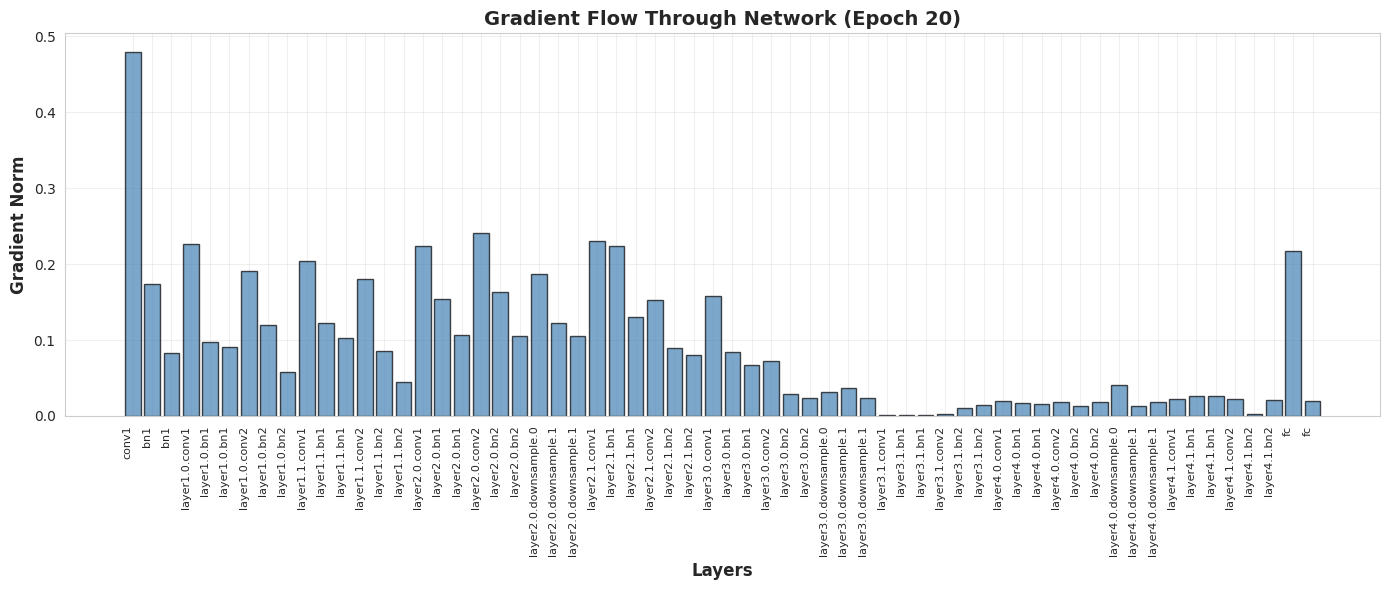

--------------------------------------------------------------------------------

Epoch 21/30
--------------------------------------------------------------------------------


Epoch 21/30 [Train]:  29%|██▉       | 91/313 [00:06<00:16, 13.14it/s, loss=0.3691, acc=89.75%]wandb: WARNING Tried to log to step 141 that is less than the current step 166. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 142 that is less than the current step 167. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 21/30 [Train]:  72%|███████▏  | 225/313 [00:16<00:05, 16.68it/s, loss=0.2922, acc=89.34%]wandb: WARNING Tried to log to step 143 that is less than the current step 168. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 144 that is less than the current step 169. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 21 Summary:
  Train Loss: 0.3018 | Train Acc: 89.47%
  Val Loss:   0.4754 | Val Acc:   84.21%
  ★ New best model saved! (Val Acc: 84.21%)
--------------------------------------------------------------------------------

Epoch 22/30
--------------------------------------------------------------------------------


Epoch 22/30 [Train]:  35%|███▌      | 110/313 [00:07<00:16, 12.07it/s, loss=0.2841, acc=89.91%]wandb: WARNING Tried to log to step 148 that is less than the current step 174. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 149 that is less than the current step 175. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 150 that is less than the current step 176. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 22/30 [Train]:  75%|███████▌  | 235/313 [00:17<00:04, 16.29it/s, loss=0.3105, acc=89.87%]wandb: WARNING Tried to log to step 151 that is less than the current step 177. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define


Epoch 22 Summary:
  Train Loss: 0.2872 | Train Acc: 89.84%
  Val Loss:   0.5023 | Val Acc:   83.58%
--------------------------------------------------------------------------------

Epoch 23/30
--------------------------------------------------------------------------------


...


Epoch 23 Summary:
  Train Loss: 0.2884 | Train Acc: 89.84%
  Val Loss:   0.4877 | Val Acc:   84.11%
--------------------------------------------------------------------------------

Epoch 24/30
--------------------------------------------------------------------------------


Epoch 24/30 [Train]:   9%|▉         | 29/313 [00:03<00:28, 10.00it/s, loss=0.2805, acc=90.36%]wandb: WARNING Tried to log to step 161 that is less than the current step 188. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 162 that is less than the current step 190. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 24/30 [Train]:  55%|█████▍    | 171/313 [00:13<00:08, 16.24it/s, loss=0.2310, acc=90.53%]wandb: WARNING Tried to log to step 163 that is less than the current step 191. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 164 that is less than the current step 192. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 24 Summary:
  Train Loss: 0.2739 | Train Acc: 90.49%
  Val Loss:   0.5288 | Val Acc:   82.69%
--------------------------------------------------------------------------------

Epoch 25/30
--------------------------------------------------------------------------------


Epoch 25/30 [Train]:  11%|█         | 33/313 [00:03<00:25, 11.18it/s, loss=0.2080, acc=90.12%]wandb: WARNING Tried to log to step 168 that is less than the current step 196. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 169 that is less than the current step 198. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 25/30 [Train]:  57%|█████▋    | 179/313 [00:13<00:08, 15.38it/s, loss=0.2766, acc=90.76%]wandb: WARNING Tried to log to step 170 that is less than the current step 199. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 171 that is less than the current step 200. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 25 Summary:
  Train Loss: 0.2715 | Train Acc: 90.64%
  Val Loss:   0.5016 | Val Acc:   84.10%

  Generating gradient flow visualization...


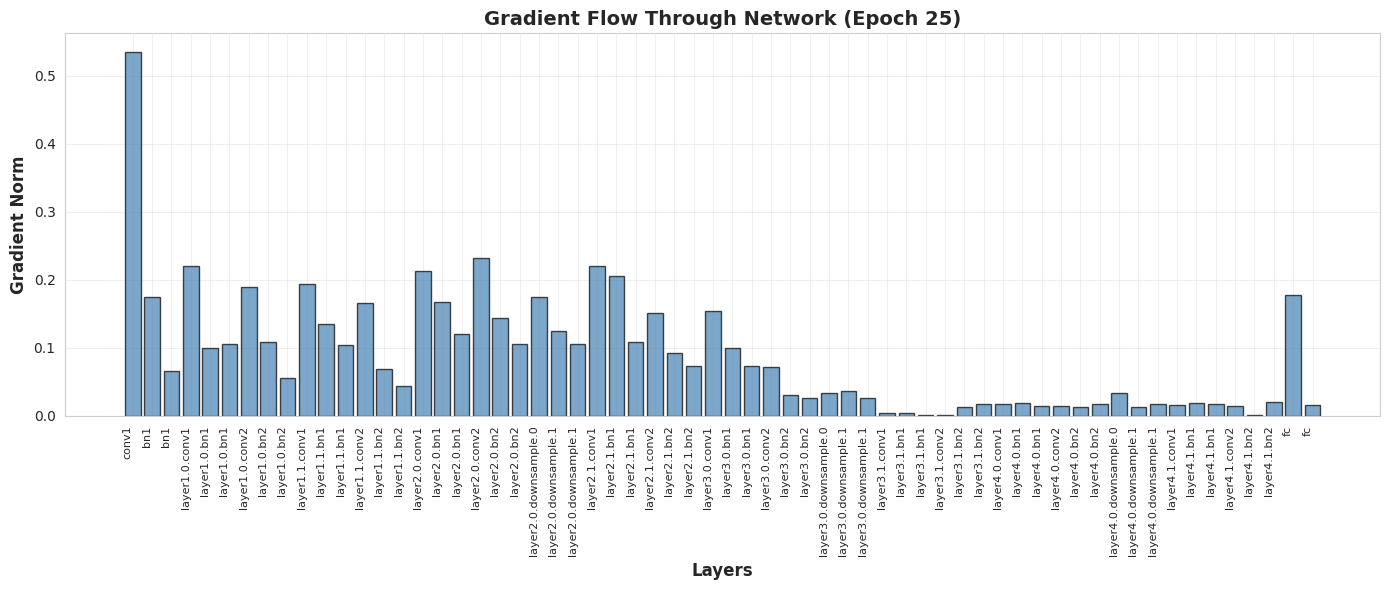

--------------------------------------------------------------------------------

Epoch 26/30
--------------------------------------------------------------------------------


Epoch 26/30 [Train]:   9%|▉         | 29/313 [00:02<00:19, 14.73it/s, loss=0.1822, acc=92.32%]wandb: WARNING Tried to log to step 175 that is less than the current step 204. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 176 that is less than the current step 207. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 26/30 [Train]:  52%|█████▏    | 162/313 [00:12<00:11, 12.61it/s, loss=0.1392, acc=92.71%]wandb: WARNING Tried to log to step 177 that is less than the current step 208. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 178 that is less than the current step 209. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 26 Summary:
  Train Loss: 0.2122 | Train Acc: 92.67%
  Val Loss:   0.4832 | Val Acc:   84.89%
  ★ New best model saved! (Val Acc: 84.89%)
--------------------------------------------------------------------------------

Epoch 27/30
--------------------------------------------------------------------------------


Epoch 27/30 [Train]:   7%|▋         | 21/313 [00:02<00:20, 14.20it/s, loss=0.1770, acc=93.82%]wandb: WARNING Tried to log to step 182 that is less than the current step 213. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 183 that is less than the current step 215. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 27/30 [Train]:  50%|█████     | 157/313 [00:12<00:15,  9.94it/s, loss=0.1564, acc=93.46%]wandb: WARNING Tried to log to step 184 that is less than the current step 216. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 185 that is less than the current step 217. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 27 Summary:
  Train Loss: 0.1913 | Train Acc: 93.39%
  Val Loss:   0.4565 | Val Acc:   85.88%
  ★ New best model saved! (Val Acc: 85.88%)
--------------------------------------------------------------------------------

Epoch 28/30
--------------------------------------------------------------------------------


...


Epoch 28 Summary:
  Train Loss: 0.1847 | Train Acc: 93.64%
  Val Loss:   0.4815 | Val Acc:   85.73%
--------------------------------------------------------------------------------

Epoch 29/30
--------------------------------------------------------------------------------


Epoch 29/30 [Train]:   6%|▌         | 19/313 [00:01<00:19, 15.00it/s, loss=0.0977, acc=94.02%]wandb: WARNING Tried to log to step 196 that is less than the current step 229. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 197 that is less than the current step 231. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 29/30 [Train]:  50%|████▉     | 155/313 [00:11<00:15,  9.97it/s, loss=0.1411, acc=94.14%]wandb: WARNING Tried to log to step 198 that is less than the current step 232. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 199 that is less than the current step 233. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 29 Summary:
  Train Loss: 0.1740 | Train Acc: 94.03%
  Val Loss:   0.4757 | Val Acc:   85.53%
--------------------------------------------------------------------------------

Epoch 30/30
--------------------------------------------------------------------------------


Epoch 30/30 [Train]:   9%|▉         | 28/313 [00:02<00:18, 15.24it/s, loss=0.1204, acc=94.42%]wandb: WARNING Tried to log to step 203 that is less than the current step 237. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 204 that is less than the current step 239. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Epoch 30/30 [Train]:  51%|█████     | 160/313 [00:12<00:14, 10.62it/s, loss=0.1739, acc=94.29%]wandb: WARNING Tried to log to step 205 that is less than the current step 240. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 206 that is less than the current step 241. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-


Epoch 30 Summary:
  Train Loss: 0.1697 | Train Acc: 94.08%
  Val Loss:   0.4961 | Val Acc:   85.62%

  Generating gradient flow visualization...


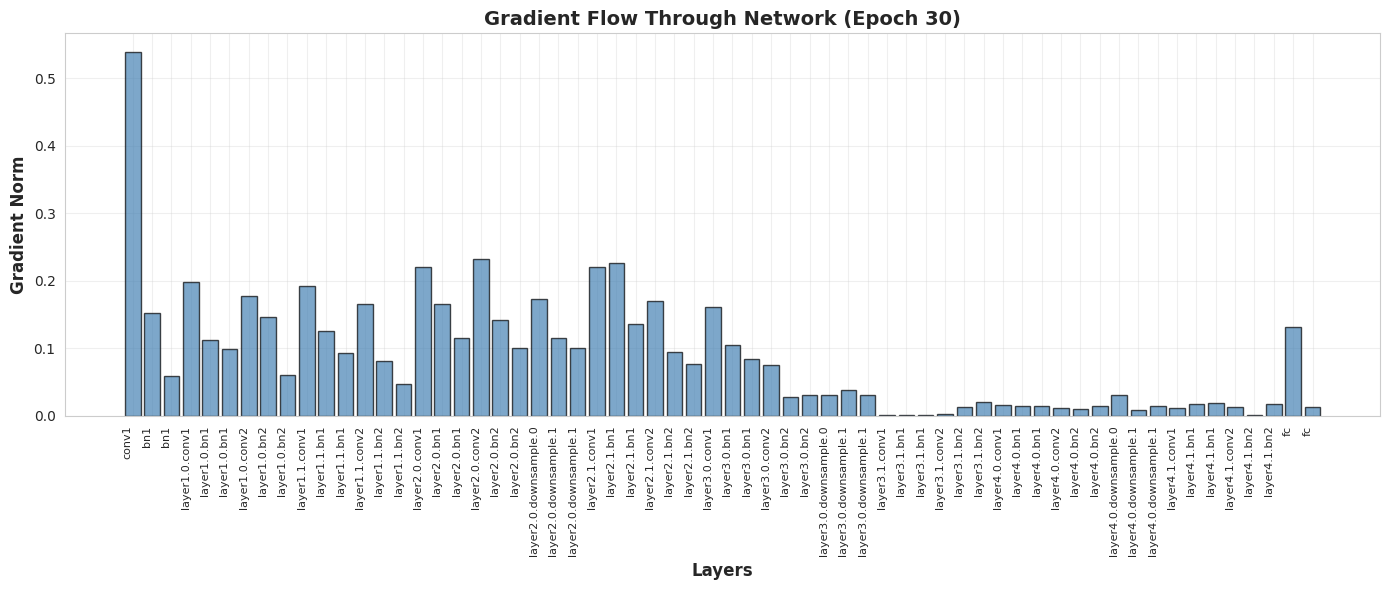

--------------------------------------------------------------------------------

TRAINING COMPLETE
Best validation accuracy: 85.88%
Best model saved to: best_model.pth


In [12]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_path = 'best_model.pth'

print("="*80)
print("STARTING TRAINING")
print("="*80)
print(f"Total epochs: {config.epochs}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print("="*80)

for epoch in range(1, config.epochs + 1):
    print(f"\nEpoch {epoch}/{config.epochs}")
    print("-"*80)

    # Train
    train_loss, train_acc = train_one_epoch(epoch)

    # Validate
    val_loss, val_acc, _, _ = evaluate(val_loader, 'Validation')

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Log to WandB
    wandb.log({
        'epoch': epoch,
        'train/loss': train_loss,
        'train/accuracy': train_acc,
        'val/loss': val_loss,
        'val/accuracy': val_acc,
    })

    # Print epoch summary
    print(f"\nEpoch {epoch} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  ★ New best model saved! (Val Acc: {best_val_acc:.2f}%)")

    # Plot gradient flow (every 5 epochs)
    if epoch % 5 == 0:
        print("\n  Generating gradient flow visualization...")
        gradient_tracker.plot_gradient_flow(epoch, save_to_wandb=True)

    print("-"*80)

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Best model saved to: {best_model_path}")

Generating comprehensive visualizations...



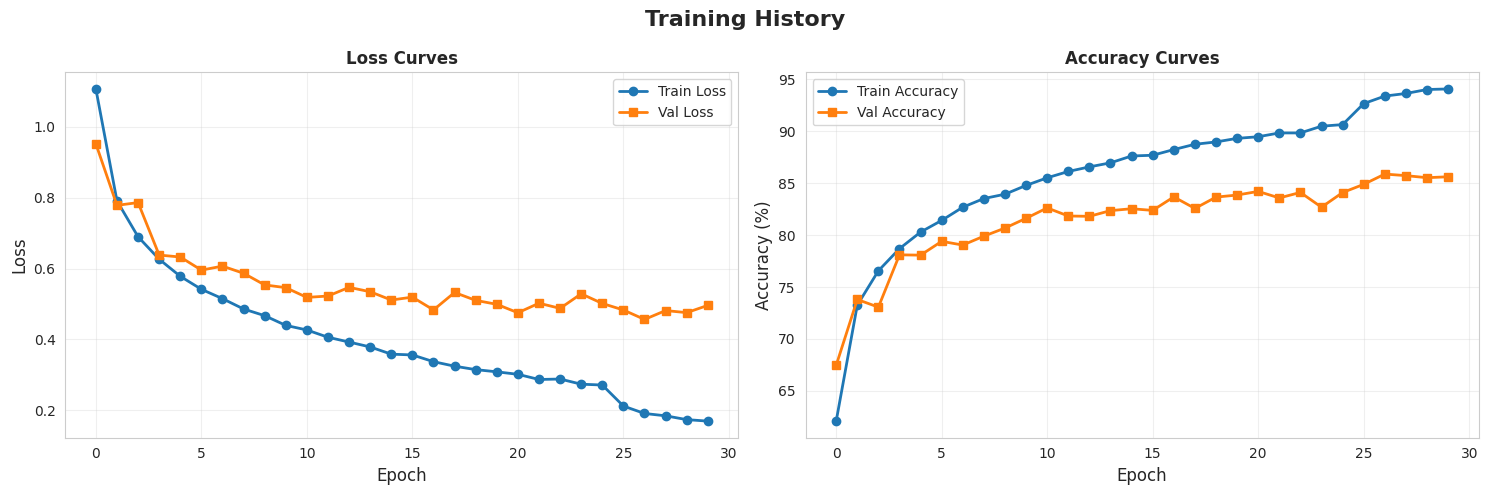


GRADIENT & WEIGHT TRACKER SUMMARY
Total steps tracked: 210

Layer-wise Statistics (Last Step):
--------------------------------------------------------------------------------

bn1.weight:
  Gradient Norm: 0.380382
  Gradient Mean: -0.001019
  Weight Norm:   2.692725
  Weight Update: 0.020011

conv1.weight:
  Gradient Norm: 0.987395
  Gradient Mean: -0.000999
  Weight Norm:   15.236149
  Weight Update: 0.228393

fc.weight:
  Gradient Norm: 0.367747
  Gradient Mean: 0.000000
  Weight Norm:   5.497675
  Weight Update: 0.129690

layer1.0.bn1.weight:
  Gradient Norm: 0.207097
  Gradient Mean: -0.002664
  Weight Norm:   2.990463
  Weight Update: 0.021380

layer1.0.bn2.weight:
  Gradient Norm: 0.198863
  Gradient Mean: -0.003265
  Weight Norm:   2.868575
  Weight Update: 0.023081

layer1.0.conv1.weight:
  Gradient Norm: 0.465164
  Gradient Mean: -0.000035
  Weight Norm:   20.183350
  Weight Update: 0.510998

layer1.0.conv2.weight:
  Gradient Norm: 0.363778
  Gradient Mean: 0.000048
  Weight

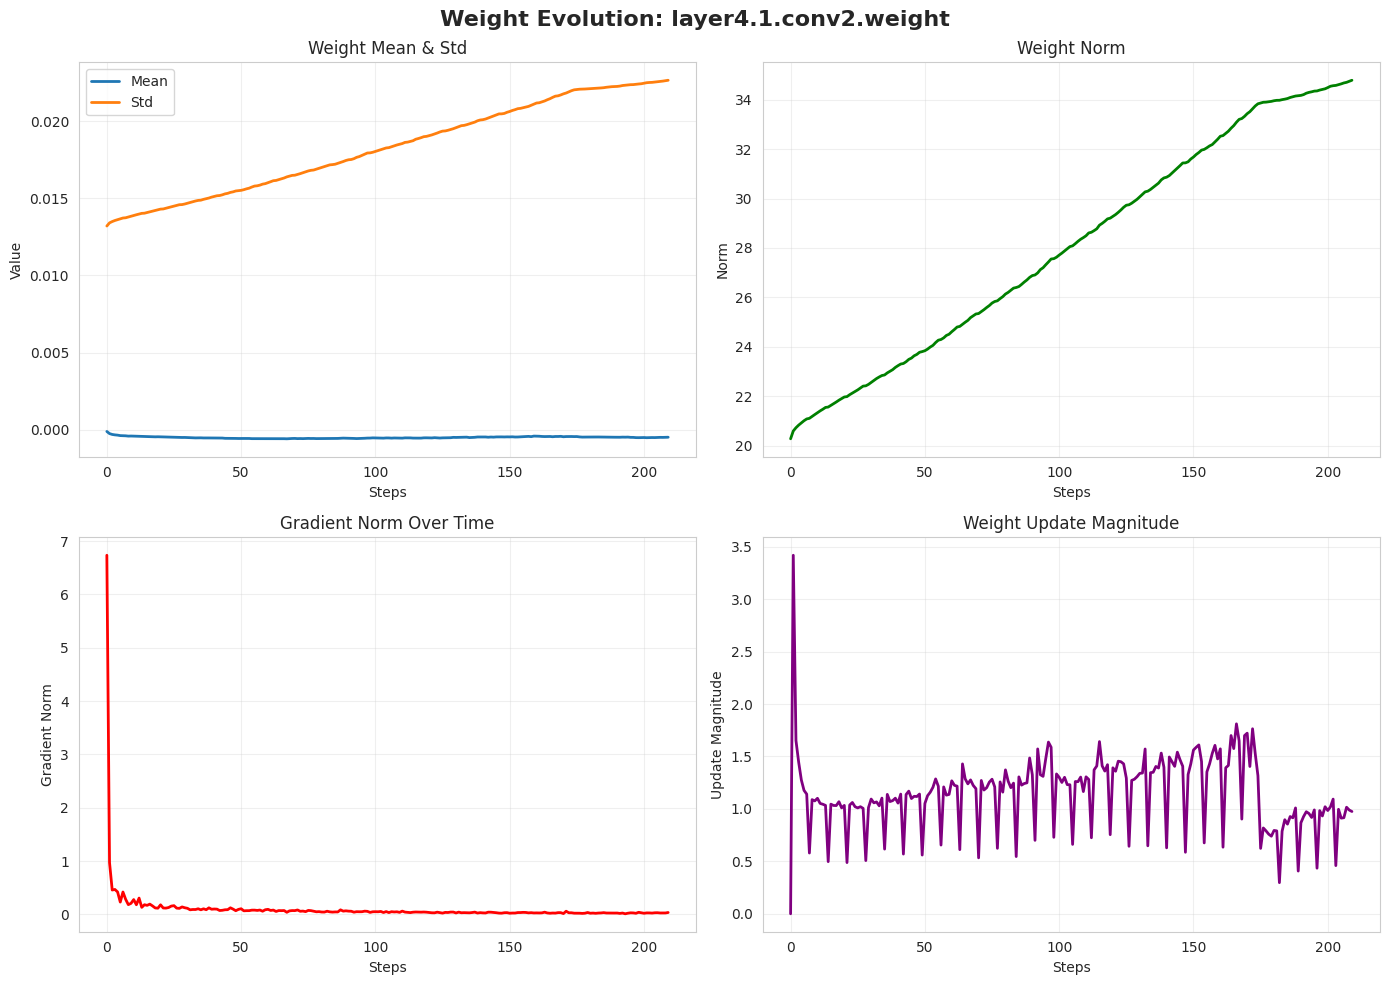

  - fc.weight


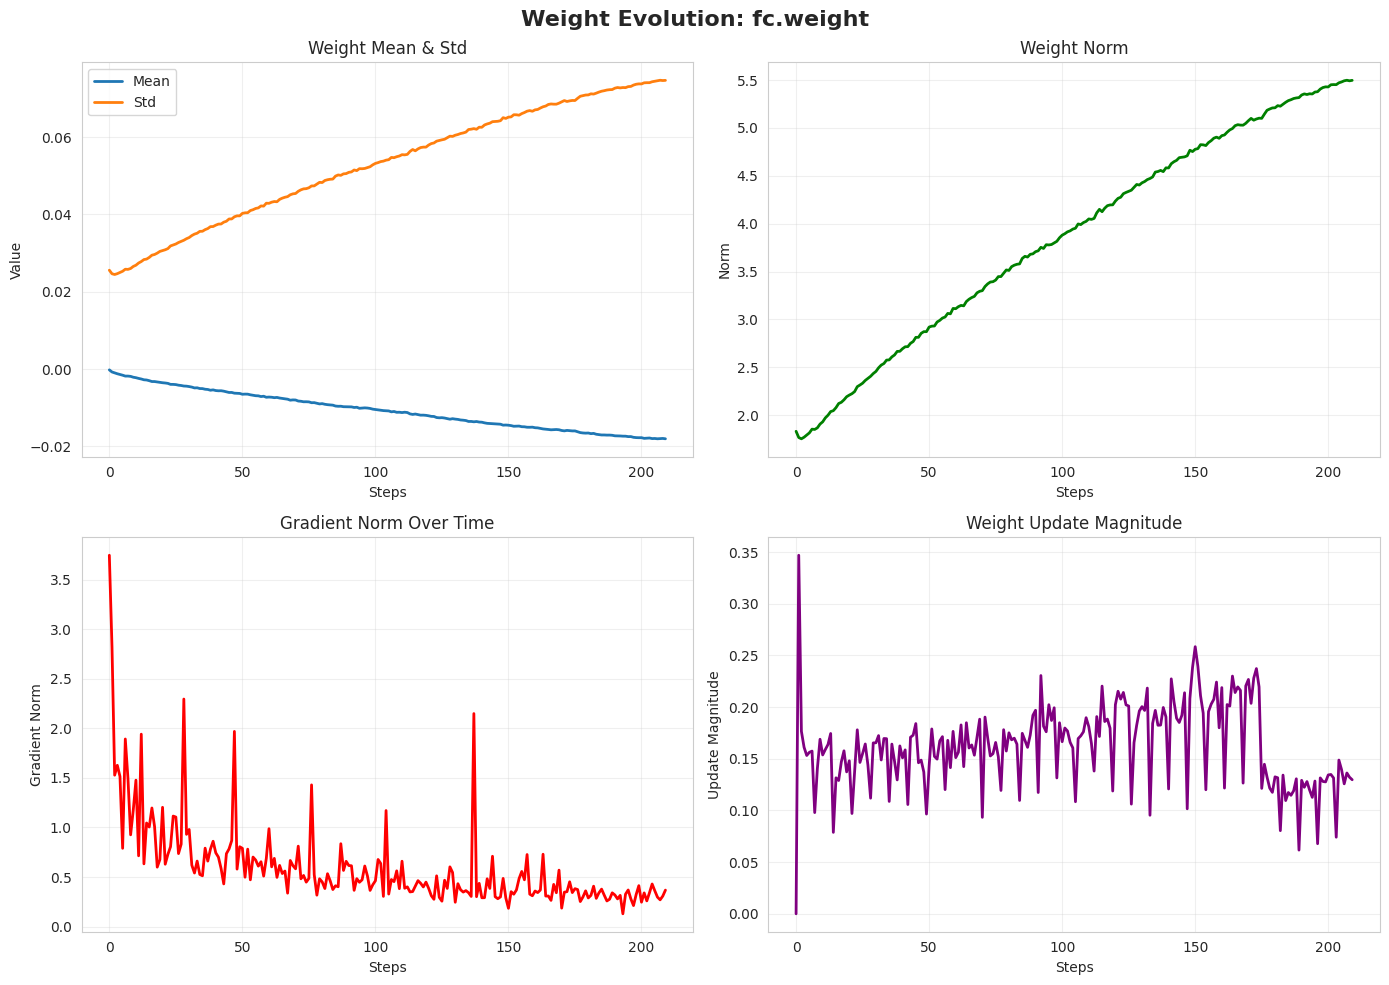


Generating gradient statistics heatmap...


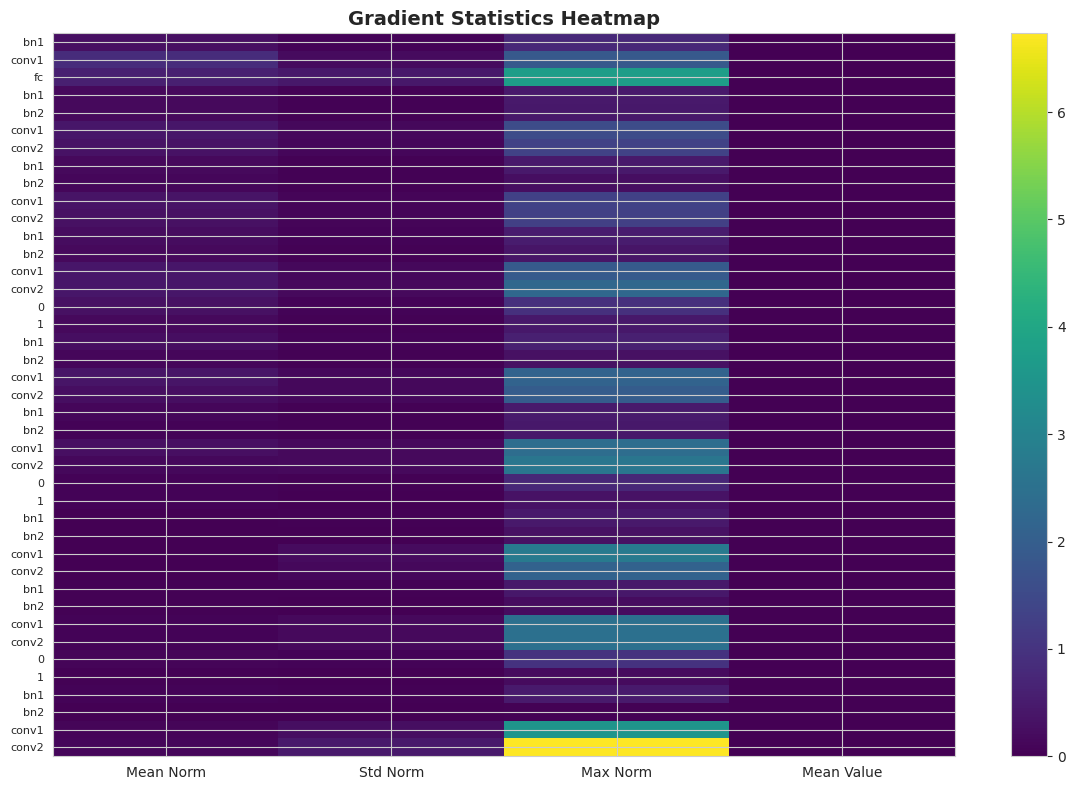


✓ All visualizations complete and logged to WandB


In [13]:
print("Generating comprehensive visualizations...\n")

# 1. Training History Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2, marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
wandb.log({"training_history": wandb.Image(fig)})
plt.show()
plt.close()

# 2. Gradient Tracker Summary
gradient_tracker.summary()

# 3. Weight Evolution for key layers
print("\nPlotting weight evolution for key layers...")
key_layers = ['layer4.1.conv2.weight', 'fc.weight']
for layer_name in key_layers:
    if layer_name in gradient_tracker.metrics:
        print(f"  - {layer_name}")
        gradient_tracker.plot_weight_evolution(layer_name, save_to_wandb=True)

# 4. Gradient Statistics Heatmap
print("\nGenerating gradient statistics heatmap...")
layer_names = []
grad_stats = []

for name in sorted(gradient_tracker.metrics.keys()):
    if 'weight' in name.lower() and len(gradient_tracker.metrics[name]['grad_norm']) > 0:
        layer_names.append(name.split('.')[-2] if '.' in name else name)
        grad_stats.append([
            np.mean(gradient_tracker.metrics[name]['grad_norm']),
            np.std(gradient_tracker.metrics[name]['grad_norm']),
            np.max(gradient_tracker.metrics[name]['grad_norm']),
            np.mean(gradient_tracker.metrics[name]['grad_mean'])
        ])

if grad_stats:
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(grad_stats, cmap='viridis', aspect='auto')

    ax.set_xticks(range(4))
    ax.set_xticklabels(['Mean Norm', 'Std Norm', 'Max Norm', 'Mean Value'])
    ax.set_yticks(range(len(layer_names)))
    ax.set_yticklabels(layer_names, fontsize=8)
    ax.set_title('Gradient Statistics Heatmap', fontsize=14, fontweight='bold')

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    wandb.log({"gradient_statistics_heatmap": wandb.Image(fig)})
    plt.show()
    plt.close()

print("\n✓ All visualizations complete and logged to WandB")

Loading best model for final evaluation...


Test: 100%|██████████| 79/79 [00:04<00:00, 17.29it/s, loss=0.5821, acc=85.54%]



FINAL TEST RESULTS
Test Loss: 0.4829
Test Accuracy: 85.54%


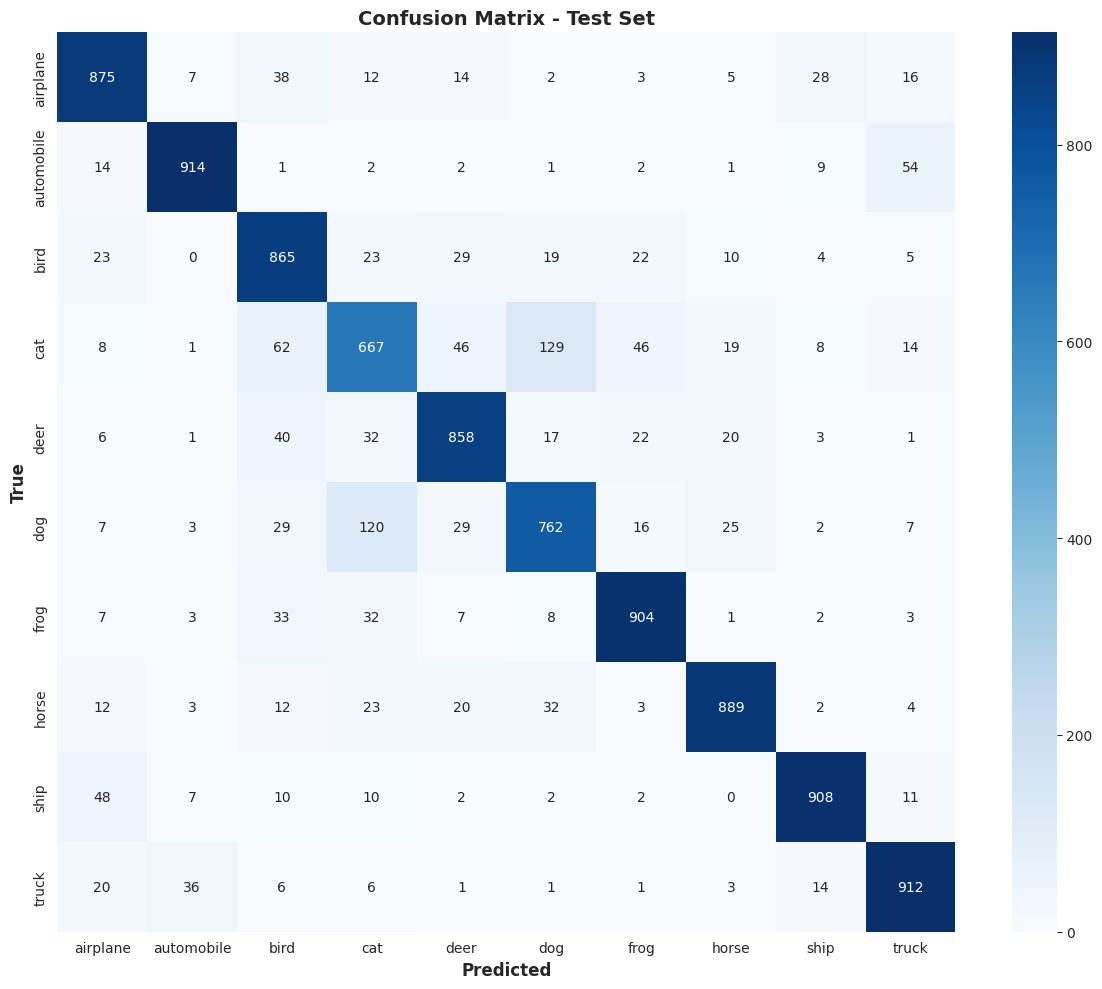


Classification Report:
              precision    recall  f1-score   support

    airplane       0.86      0.88      0.87      1000
  automobile       0.94      0.91      0.93      1000
        bird       0.79      0.86      0.83      1000
         cat       0.72      0.67      0.69      1000
        deer       0.85      0.86      0.85      1000
         dog       0.78      0.76      0.77      1000
        frog       0.89      0.90      0.89      1000
       horse       0.91      0.89      0.90      1000
        ship       0.93      0.91      0.92      1000
       truck       0.89      0.91      0.90      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.85     10000
weighted avg       0.86      0.86      0.85     10000


Per-Class Accuracy:
--------------------------------------------------------------------------------
airplane    :  87.50% (875/1000)
automobile  :  91.40% (914/1000)
bird        :  86.50% (865/1000)
cat         :  6

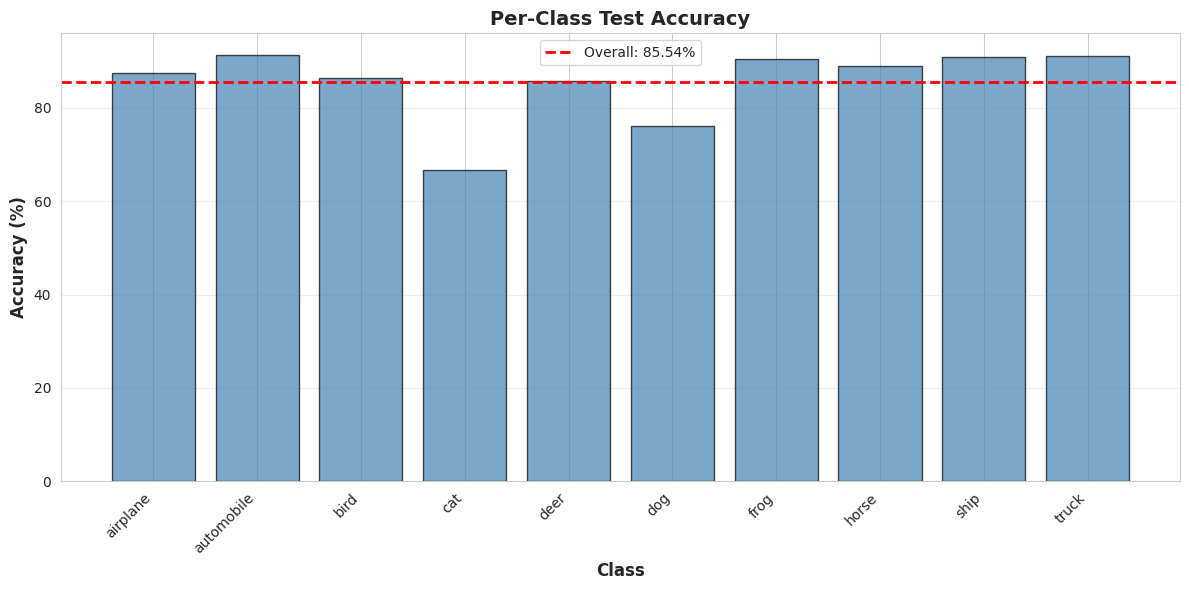

In [14]:
# Load best model
print("Loading best model for final evaluation...")
model.load_state_dict(torch.load(best_model_path))

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(test_loader, 'Test')

print("\n" + "="*80)
print("FINAL TEST RESULTS")
print("="*80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("="*80)

# Log to WandB
wandb.log({
    'test/loss': test_loss,
    'test/accuracy': test_acc
})

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(test_labels, test_preds)
class_names = test_dataset.classes

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('True', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.show()
plt.close()

# Classification Report
print("\nClassification Report:")
print("="*80)
print(classification_report(test_labels, test_preds, target_names=class_names))

# Per-class accuracy
class_correct = [0] * 10
class_total = [0] * 10

for pred, label in zip(test_preds, test_labels):
    if pred == label:
        class_correct[label] += 1
    class_total[label] += 1

print("\nPer-Class Accuracy:")
print("-"*80)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_names[i]:12s}: {acc:6.2f}% ({class_correct[i]}/{class_total[i]})")

# Bar plot of per-class accuracy
class_accuracies = [100 * class_correct[i] / class_total[i] for i in range(10)]
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(class_names, class_accuracies, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Test Accuracy', fontsize=14, fontweight='bold')
ax.axhline(y=test_acc, color='red', linestyle='--', linewidth=2, label=f'Overall: {test_acc:.2f}%')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
wandb.log({"per_class_accuracy": wandb.Image(fig)})
plt.show()
plt.close()

In [15]:
print("\n" + "="*80)
print("COMPREHENSIVE FINDINGS AND OBSERVATIONS")
print("="*80)

print("\n1. MODEL ARCHITECTURE")
print("-"*80)
print(f"Model: Pre-trained ResNet18 fine-tuned for CIFAR-10")
print(f"Total Parameters: {params:,}")
print(f"Total FLOPs: {flops:,.0f}")
print(f"Model Size: {param_memory:.2f} MB")

print("\n2. DATASET INFORMATION")
print("-"*80)
print(f"Dataset: CIFAR-10")
print(f"Training samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of classes: 10")

print("\n3. TRAINING CONFIGURATION")
print("-"*80)
print(f"Total epochs: {config.epochs}")
print(f"Optimizer: Adam")
print(f"Initial learning rate: {config.learning_rate}")
print(f"Loss function: CrossEntropyLoss")
print(f"Scheduler: ReduceLROnPlateau")
print(f"Gradient clipping: max_norm=1.0")

print("\n4. TRAINING RESULTS")
print("-"*80)
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Final test accuracy: {test_acc:.2f}%")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final validation loss: {history['val_loss'][-1]:.4f}")
print(f"Final test loss: {test_loss:.4f}")

print("\n5. COMPUTATIONAL ANALYSIS")
print("-"*80)
print(f"FLOPs per forward pass: {flops_per_sample:,.0f}")
print(f"FLOPs per batch: {flops_per_batch:,.0f}")
print(f"Total FLOPs for training: {total_flops_training:.2e}")
print(f"Estimated memory usage: {total_memory:.2f} MB")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nAll results and visualizations are available at: {wandb.run.url}")

# Create summary table
summary_data = {
    'Metric': [
        'Total Parameters',
        'Total FLOPs',
        'Best Val Accuracy',
        'Test Accuracy',
        'Training Time (epochs)',
        'Final Train Loss',
        'Final Val Loss',
        'Test Loss'
    ],
    'Value': [
        f"{params:,}",
        f"{flops:.2e}",
        f"{best_val_acc:.2f}%",
        f"{test_acc:.2f}%",
        f"{config.epochs}",
        f"{history['train_loss'][-1]:.4f}",
        f"{history['val_loss'][-1]:.4f}",
        f"{test_loss:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

# Log summary table to WandB
wandb.log({"summary_table": wandb.Table(dataframe=summary_df)})


COMPREHENSIVE FINDINGS AND OBSERVATIONS

1. MODEL ARCHITECTURE
--------------------------------------------------------------------------------
Model: Pre-trained ResNet18 fine-tuned for CIFAR-10
Total Parameters: 11,181,642.0
Total FLOPs: 37,220,352
Model Size: 42.65 MB

2. DATASET INFORMATION
--------------------------------------------------------------------------------
Dataset: CIFAR-10
Training samples: 40,000
Validation samples: 10,000
Test samples: 10,000
Batch size: 128
Number of classes: 10

3. TRAINING CONFIGURATION
--------------------------------------------------------------------------------
Total epochs: 30
Optimizer: Adam
Initial learning rate: 0.001
Loss function: CrossEntropyLoss
Scheduler: ReduceLROnPlateau
Gradient clipping: max_norm=1.0

4. TRAINING RESULTS
--------------------------------------------------------------------------------
Best validation accuracy: 85.88%
Final test accuracy: 85.54%
Final train loss: 0.1697
Final validation loss: 0.4961
Final test l

In [16]:
wandb.finish()

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
model/flops_per_batch,▁
model/flops_per_sample,▁
model/param_memory_mb,▁
model/total_flops,▁
model/total_memory_mb,▁
model/total_params,▁
model/total_training_flops,▁
test/accuracy,▁
test/loss,▁
+7,...
